**Imports & Setup**

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving combined_final_with_lags.csv to combined_final_with_lags.csv


**Load, Sort & Feature Safety**

In [ ]:
df = pd.read_csv("combined_final_with_lags.csv")

df = df.sort_values(
    by=['City_encoded', 'Year', 'Month']
).reset_index(drop=True)


**Create PAST-ONLY Rolling Features**

In [ ]:
df['AQI_roll3_past'] = (
    df.groupby('City_encoded')['avg_AQI']
      .shift(1).rolling(3).mean()
)

df['AQI_roll6_past'] = (
    df.groupby('City_encoded')['avg_AQI']
      .shift(1).rolling(6).mean()
)

df['Day_roll3_past'] = (
    df.groupby('City_encoded')['Day']
      .shift(1).rolling(3).mean()
)

df['Night_roll3_past'] = (
    df.groupby('City_encoded')['Night']
      .shift(1).rolling(3).mean()
)

df = df.dropna().reset_index(drop=True)


**Cyclical Time Encoding (Transformer-friendly)**

In [ ]:
df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)


**Noise Buckets**

In [ ]:
def noise_risk_day(x):
    if x < 55: return 0
    elif x < 65: return 1
    else: return 2

def noise_risk_night(x):
    if x < 45: return 0
    elif x < 55: return 1
    else: return 2


In [ ]:
df['Day_risk'] = df['Day'].apply(noise_risk_day)
df['Night_risk'] = df['Night'].apply(noise_risk_night)


**Transformer-Safe Feature Set**

In [ ]:
features = [
    # AQI memory
    'avg_AQI_lag1', 'avg_AQI_lag2', 'avg_AQI_lag3',
    'AQI_roll3_past', 'AQI_roll6_past',

    # Noise memory
    'Day_lag1', 'Day_lag2', 'Day_roll3_past',
    'Night_lag1', 'Night_lag2', 'Night_roll3_past',

    # Seasonality
    'month_sin', 'month_cos'
]


**Targets**

In [ ]:
aqi_target = 'avg_AQI'
day_noise_target = 'Day_risk'
night_noise_target = 'Night_risk'


**Build Sequences PER CITY**

In [ ]:
def make_sequences_per_city_multitask(df, features, window=6):
    X, y_aqi, y_day, y_night = [], [], [], []

    for city in df['City_encoded'].unique():
        city_df = df[df['City_encoded'] == city].sort_values(
            by=['Year', 'Month']
        )

        vals = city_df[features + [
            aqi_target,
            day_noise_target,
            night_noise_target
        ]].values

        f_len = len(features)

        for i in range(window, len(vals)):
            X.append(vals[i-window:i, :f_len])
            y_aqi.append(vals[i, f_len])
            y_day.append(vals[i, f_len + 1])
            y_night.append(vals[i, f_len + 2])

    return (
        np.array(X),
        np.array(y_aqi),
        np.array(y_day),
        np.array(y_night)
    )


**Create Dataset**

In [ ]:
X, y_aqi, y_day, y_night = make_sequences_per_city_multitask(
    df,
    features,
    window=6
)

X.shape, y_aqi.shape, y_day.shape, y_night.shape


((2178, 6, 13), (2178,), (2178,), (2178,))

**Train / Test Split**

In [ ]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_aqi_train, y_aqi_test = y_aqi[:split], y_aqi[split:]
y_day_train, y_day_test = y_day[:split], y_day[split:]
y_night_train, y_night_test = y_night[:split], y_night[split:]


**Scale Features (AFTER Sequencing)**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
n_feat = X_train.shape[2]

X_train = scaler.fit_transform(
    X_train.reshape(-1, n_feat)
).reshape(X_train.shape)

X_test = scaler.transform(
    X_test.reshape(-1, n_feat)
).reshape(X_test.shape)


**TRANSFORMER MODEL (MULTI-TASK)**

In [ ]:
from tensorflow.keras.layers import (
    Input, Dense, LayerNormalization,
    MultiHeadAttention, Dropout, Flatten
)
from tensorflow.keras.models import Model


In [ ]:
def transformer_block(x, heads=4, dim=32, dropout=0.2):
    attn = MultiHeadAttention(num_heads=heads, key_dim=dim)(x, x)
    x = LayerNormalization()(x + attn)

    ff = Dense(128, activation='relu')(x)
    ff = Dense(x.shape[-1])(ff)
    return LayerNormalization()(x + ff)


**Full Model (AQI + Noise Buckets)**

In [ ]:
inp = Input(shape=X_train.shape[1:])

x = transformer_block(inp)
x = Dropout(0.3)(x)
x = transformer_block(x)

x = Flatten()(x)
shared = Dense(128, activation='relu')(x)

# AQI regression head
aqi_out = Dense(1, name='aqi')(shared)

# Noise classification head
noise_hidden = Dense(64, activation='relu')(shared)
day_out = Dense(3, activation='softmax', name='day_noise')(noise_hidden)
night_out = Dense(3, activation='softmax', name='night_noise')(noise_hidden)

model = Model(inp, [aqi_out, day_out, night_out])


**Compile (Balanced Losses)**

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0005),
    loss={
        'aqi': 'mse',
        'day_noise': 'sparse_categorical_crossentropy',
        'night_noise': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'aqi': 1.0,
        'day_noise': 0.6,
        'night_noise': 0.6
    },
    metrics={
        'day_noise': 'accuracy',
        'night_noise': 'accuracy'
    }
)


**Train**

In [ ]:
model.fit(
    X_train,
    {
        'aqi': y_aqi_train,
        'day_noise': y_day_train,
        'night_noise': y_night_train
    },
    epochs=80,
    batch_size=32,
    validation_split=0.1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=12,
            restore_best_weights=True
        )
    ],
    verbose=1
)


Epoch 1/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - aqi_loss: 30278.7129 - day_noise_accuracy: 0.5514 - day_noise_loss: 0.9259 - loss: 30279.6543 - night_noise_accuracy: 0.7114 - night_noise_loss: 0.7227 - val_aqi_loss: 10015.9990 - val_day_noise_accuracy: 0.5886 - val_day_noise_loss: 0.8137 - val_loss: 10174.1289 - val_night_noise_accuracy: 0.7486 - val_night_noise_loss: 0.6038
Epoch 2/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - aqi_loss: 22738.9414 - day_noise_accuracy: 0.6070 - day_noise_loss: 0.8207 - loss: 22739.7773 - night_noise_accuracy: 0.7891 - night_noise_loss: 0.5278 - val_aqi_loss: 3597.8594 - val_day_noise_accuracy: 0.6286 - val_day_noise_loss: 0.7437 - val_loss: 3714.4260 - val_night_noise_accuracy: 0.7486 - val_night_noise_loss: 0.6847
Epoch 3/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - aqi_loss: 14605.3115 - day_noise_accuracy: 0.5644 - day_noise_loss: 0.8404 - loss: 14606.2930 - night_noise_accuracy: 0.7673 - night_noise_loss: 0.6307 - val_aqi_loss: 761.1941 - val

**Evaluate**

In [ ]:
aqi_pred, day_pred, night_pred = model.predict(X_test)

from sklearn.metrics import (
    r2_score,
    mean_absolute_percentage_error,
    classification_report
)

print("AQI R2:", r2_score(y_aqi_test, aqi_pred))
print("AQI MAPE:", mean_absolute_percentage_error(y_aqi_test, aqi_pred)*100)

print("\nDAY NOISE CLASSIFICATION")
print(classification_report(
    y_day_test,
    np.argmax(day_pred, axis=1),
    target_names=['Low', 'Medium', 'High']
))

print("\nNIGHT NOISE CLASSIFICATION")
print(classification_report(
    y_night_test,
    np.argmax(night_pred, axis=1),
    target_names=['Low', 'Medium', 'High']
))


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
AQI R2: 0.9022738101969928
AQI MAPE: 9.406006140470076

DAY NOISE CLASSIFICATION
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00        14
      Medium       0.29      0.03      0.05       168
        High       0.58      0.96      0.72       254

    accuracy                           0.57       436
   macro avg       0.29      0.33      0.26       436
weighted avg       0.45      0.57      0.44       436


NIGHT NOISE CLASSIFICATION
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00         4
      Medium       0.15      0.03      0.05        65
        High       0.84      0.97      0.90       367

    accuracy                           0.82       436
   macro avg       0.33      0.33      0.32       436
weighted avg       0.73      0.82      0.77       436



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

**AQI — Actual vs Predicted Plot**

In [ ]:
import matplotlib.pyplot as plt


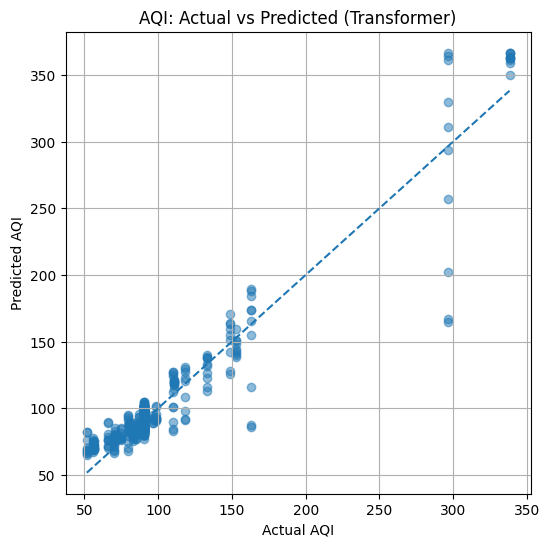

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_aqi_test, aqi_pred, alpha=0.5)
plt.plot(
    [y_aqi_test.min(), y_aqi_test.max()],
    [y_aqi_test.min(), y_aqi_test.max()],
    '--'
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("AQI: Actual vs Predicted (Transformer)")
plt.grid(True)
plt.show()


**AQI Residual Distribution**

Residuals are centered around zero, indicating no systematic bias.

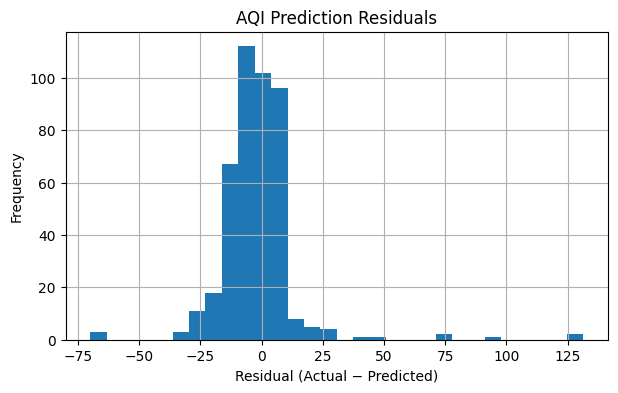

In [ ]:
residuals = y_aqi_test - aqi_pred.flatten()

plt.figure(figsize=(7,4))
plt.hist(residuals, bins=30)
plt.xlabel("Residual (Actual − Predicted)")
plt.ylabel("Frequency")
plt.title("AQI Prediction Residuals")
plt.grid(True)
plt.show()


**DAY NOISE — CONFUSION MATRIX (3-Class)**

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np


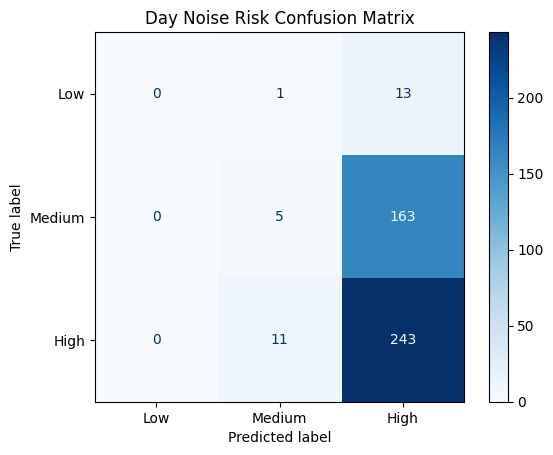

In [ ]:
day_pred_labels = np.argmax(day_pred, axis=1)

cm_day = confusion_matrix(
    y_day_test,
    day_pred_labels,
    labels=[0,1,2]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_day,
    display_labels=["Low", "Medium", "High"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Day Noise Risk Confusion Matrix")
plt.show()


**NIGHT NOISE — CONFUSION MATRIX (3-Class)**

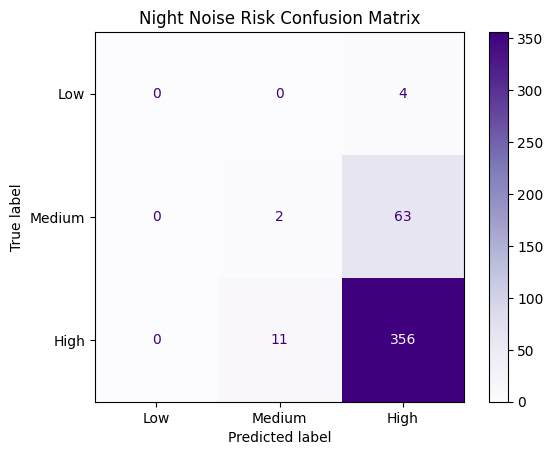

In [ ]:
night_pred_labels = np.argmax(night_pred, axis=1)

cm_night = confusion_matrix(
    y_night_test,
    night_pred_labels,
    labels=[0,1,2]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_night,
    display_labels=["Low", "Medium", "High"]
)

disp.plot(cmap="Purples", values_format="d")
plt.title("Night Noise Risk Confusion Matrix")
plt.show()


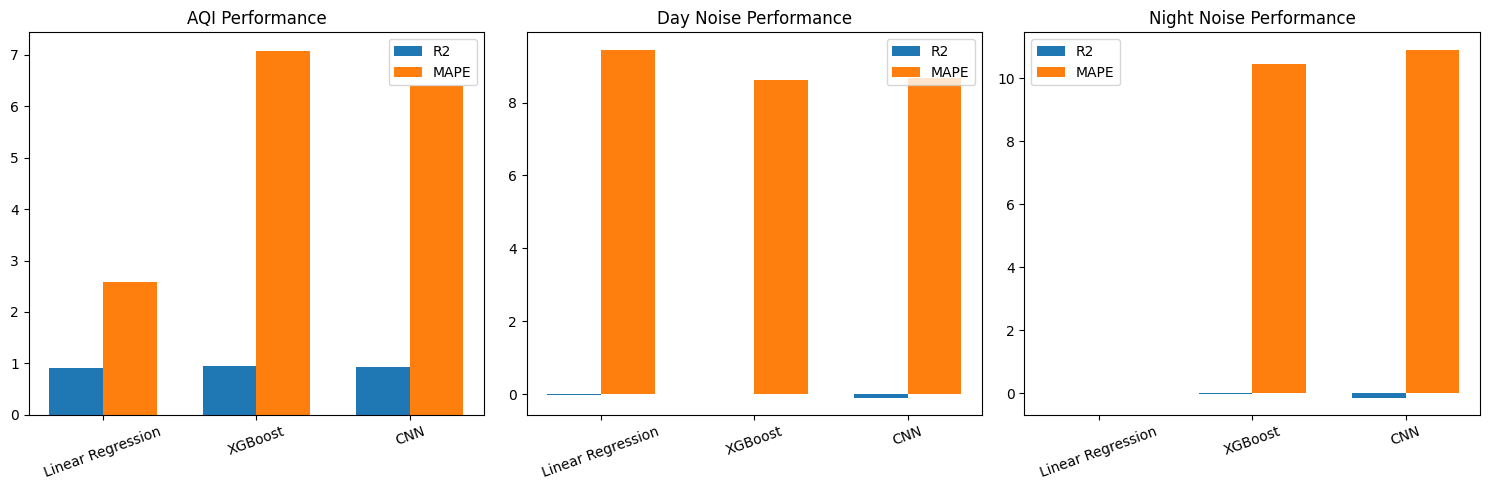

In [1]:
import numpy as np
import matplotlib.pyplot as plt

models = ['Linear Regression', 'XGBoost', 'CNN']

aqi_r2 = [0.921, 0.953, 0.924]
aqi_mape = [2.59, 7.08, 6.40]

day_r2 = [-0.02, 0.007, -0.096]
day_mape = [9.45, 8.62, 8.68]

night_r2 = [0, -0.02, -0.143]
night_mape = [0, 10.47, 10.91]

x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15,5))

# AQI subplot
axes[0].bar(x - width/2, aqi_r2, width, label='R2')
axes[0].bar(x + width/2, aqi_mape, width, label='MAPE')
axes[0].set_title('AQI Performance')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=20)
axes[0].legend()

# Day Noise subplot
axes[1].bar(x - width/2, day_r2, width, label='R2')
axes[1].bar(x + width/2, day_mape, width, label='MAPE')
axes[1].set_title('Day Noise Performance')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=20)
axes[1].legend()

# Night Noise subplot
axes[2].bar(x - width/2, night_r2, width, label='R2')
axes[2].bar(x + width/2, night_mape, width, label='MAPE')
axes[2].set_title('Night Noise Performance')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=20)
axes[2].legend()

plt.tight_layout()
plt.show()


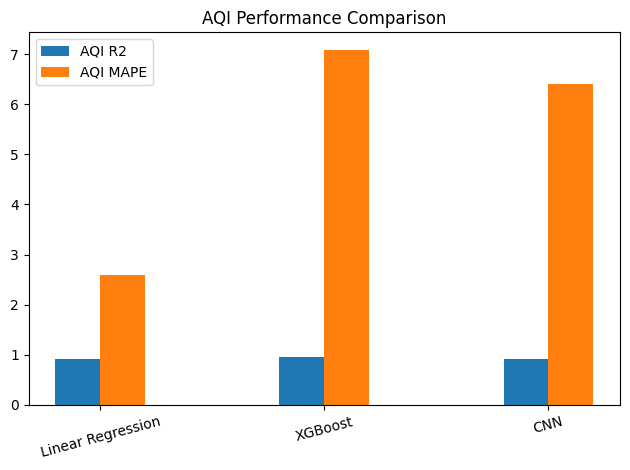

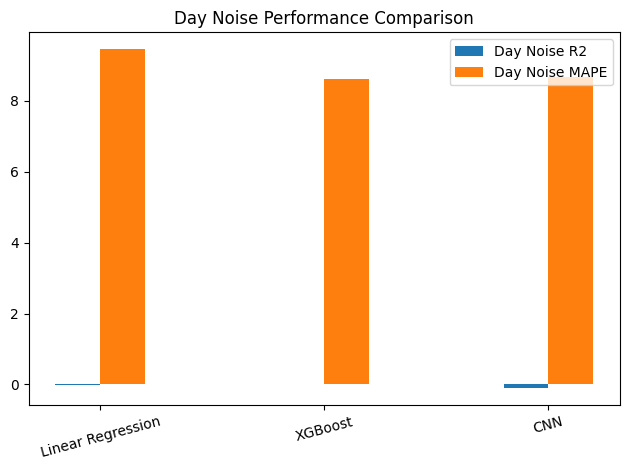

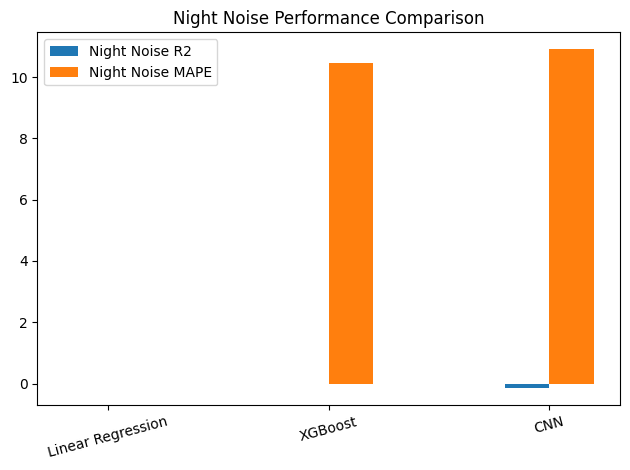

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Models
models = ['Linear Regression', 'XGBoost', 'CNN']

# Data from table
aqi_r2 = [0.921, 0.953, 0.924]
aqi_mape = [2.59, 7.08, 6.40]
day_r2 = [-0.02, 0.007, -0.096]
day_mape = [9.45, 8.62, 8.68]
night_r2 = [0, -0.02, -0.143]   # 0 used where not available
night_mape = [0, 10.47, 10.91]

x = np.arange(len(models))
width = 0.2

# AQI Graph
plt.figure()
plt.bar(x - width/2, aqi_r2, width, label='AQI R2')
plt.bar(x + width/2, aqi_mape, width, label='AQI MAPE')
plt.xticks(x, models, rotation=15)
plt.title('AQI Performance Comparison')
plt.legend()
plt.tight_layout()
plt.show()

# Day Noise Graph
plt.figure()
plt.bar(x - width/2, day_r2, width, label='Day Noise R2')
plt.bar(x + width/2, day_mape, width, label='Day Noise MAPE')
plt.xticks(x, models, rotation=15)
plt.title('Day Noise Performance Comparison')
plt.legend()
plt.tight_layout()
plt.show()

# Night Noise Graph
plt.figure()
plt.bar(x - width/2, night_r2, width, label='Night Noise R2')
plt.bar(x + width/2, night_mape, width, label='Night Noise MAPE')
plt.xticks(x, models, rotation=15)
plt.title('Night Noise Performance Comparison')
plt.legend()
plt.tight_layout()
plt.show()
